bonjour

In [ ]:
COLAB = "google.colab" in str(get_ipython())

In [ ]:
if COLAB:
    ! git clone --depth 1 https://github.com/ST4-BlackSwan/Higgs-TeamB.git

    %cd Higgs-TeamB

    ! git status

Cloning into 'Higgs-TeamB'...
remote: Enumerating objects: 40, done.
remote: Counting objects: 100% (40/40), done.
remote: Compressing objects: 100% (35/35), done.
remote: Total 40 (delta 2), reused 19 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (40/40), 1.43 MiB | 8.15 MiB/s, done.
Resolving deltas: 100% (2/2), done.
/content/Higgs-TeamB
On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean


In [ ]:
%cd /content
!rm -rf Higgs-TeamB
!git clone -b main https://github.com/ST4-BlackSwan/Higgs-TeamB.git

/content
Cloning into 'Higgs-TeamB'...
remote: Enumerating objects: 731, done.
remote: Counting objects: 100% (191/191), done.
remote: Compressing objects: 100% (110/110), done.
remote: Total 731 (delta 121), reused 87 (delta 81), pack-reused 540 (from 2)
Receiving objects: 100% (731/731), 12.47 MiB | 14.34 MiB/s, done.
Resolving deltas: 100% (395/395), done.


In [ ]:
# HiggsML utility package should not be modified
%pip install HiggsML==0.1.5
%pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.1/203.1 kB 24.3 MB/s eta 0:00:00


In [ ]:
from sys import path
import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt
from itertools import product
from numpy.random import RandomState
import warnings
import os
import sys

warnings.filterwarnings("ignore")

In [ ]:
import os

root_dir = os.getcwd()
print("Root directory is", root_dir)

submission_dir = os.path.join(os.path.dirname(root_dir), "sample_code_submission")

# The directory where results and other outputs from the participant's code will be written
output_dir = os.path.join(root_dir, "sample_result_submission")

if not os.path.exists(output_dir):
    os.makedirs(output_dir)


# Remove cached modules if they exist to force reload
if "model" in sys.modules:
    del sys.modules["model"]
if "sort_signal_background" in sys.modules:
    del sys.modules["sort_signal_background"]

# Ensure submission_dir is in sys.path. Remove and re-add to ensure order/freshness.
if submission_dir in sys.path:
    sys.path.remove(submission_dir)
sys.path.append(submission_dir)

Root directory is /content


In [ ]:
!git fetch origin
!git pull origin main
!git branch

fatal: not a git repository (or any of the parent directories): .git
fatal: not a git repository (or any of the parent directories): .git
fatal: not a git repository (or any of the parent directories): .git


--- 1. Chargement et Nettoyage des données ---
--- 2. Affichage des distributions (optionnel) ---


<Figure size 640x480 with 0 Axes>

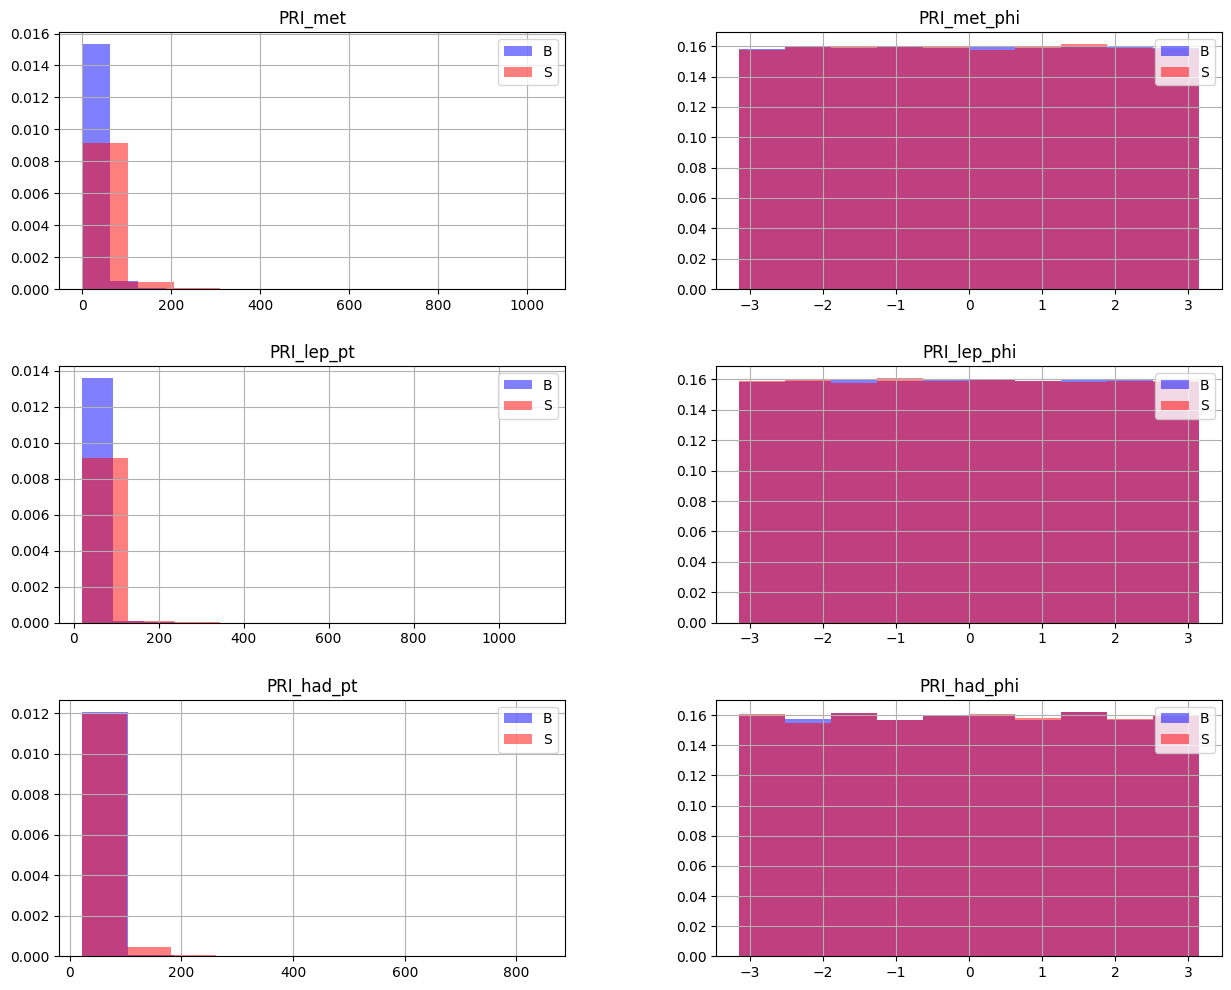

--- 3. Séparation, Scaler et Renormalisation des poids ---

[Vérification des Shapes]
Train features: (1050000, 6) | Test features: (350000, 6)
Somme des poids Train - Bkg: 78794.65 | Signal: 78794.65


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# TENTATIVE D'IMPORTATION DE HIGGSML (avec fallback si exécuté en local)
try:
    from HiggsML.datasets import download_dataset
except ImportError:
    print("Attention: La librairie HiggsML n'est pas installée localement.")


def load_and_clean_blackswan():
    """
    Télécharge, charge et nettoie les données spécifiques au challenge.
    Version corrigée avec les colonnes exactes du dataset BlackSwan (labels, weights, PRI_*).
    """
    # 1. Téléchargement et chargement via l'API HiggsML
    dataset = download_dataset("blackSwan_data")
    dataset.load_train_set()
    df_raw = dataset.get_train_set()

    # Conversion en DataFrame standard si nécessaire
    if not isinstance(df_raw, pd.DataFrame):
        if hasattr(df_raw, "df"):
            df_raw = df_raw.df
        else:
            df_raw = pd.DataFrame(df_raw)

    # 2. Extraction de la cible ('labels') et conversion automatique en 0/1 si c'est du texte
    target = df_raw["labels"].copy()
    if target.dtype == "object" or target.dtype == "string":
        target = target.map({"s": 1, "b": 0, "S": 1, "B": 0, 1: 1, 0: 0})

    # 3. Extraction des poids ('weights')
    weights = df_raw["weights"].copy()

    # 4. Sélection des features pertinentes pour l'exercice
    # On mappe les variables demandées vers leurs équivalents exacts dans ton dataset :
    # "met_et" -> "PRI_met", "lep_pt_0" -> "PRI_lep_pt", etc.
    feature_mapping = {
        "PRI_met": "PRI_met",
        "PRI_met_phi": "PRI_met_phi",
        "PRI_lep_pt": "PRI_lep_pt",
        "PRI_lep_phi": "PRI_lep_phi",
        "PRI_had_pt": "PRI_had_pt",
        "PRI_had_phi": "PRI_had_phi",
    }

    available_features = [
        col for col in feature_mapping.keys() if col in df_raw.columns
    ]

    if len(available_features) == 0:
        print(
            "Warning: Les features spécifiques ciblées sont introuvables. Utilisation de toutes les variables DER/PRI."
        )
        # Sécurité : On prend tout sauf les colonnes de cibles et de poids
        features = df_raw.drop(
            columns=["labels", "detailed_labels", "weights"], errors="ignore"
        )
    else:
        features = df_raw[available_features].copy()

    # Remplacement des valeurs manquantes (NaN ou indéfinies) par la moyenne
    features = features.fillna(features.mean())

    return features, target, weights


def prepare_datasets(features, target, weights, train_size=0.75, random_seed=31415):
    """
    Sépare en Train/Test, applique le StandardScaler et normalise les poids.
    """
    # Fixer la seed pour la reproductibilité
    np.random.seed(random_seed)

    # 1. Séparation Train / Test
    X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
        features, target, weights, train_size=train_size, random_state=random_seed
    )

    # conversion en copies explicites pour éviter les SettingWithCopyWarning
    w_train = w_train.copy()
    w_test = w_test.copy()

    # 2. Standardisation (Moyenne 0, Variance 1)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # 3. Renormalisation des poids (Code d'égalisation du notebook original)
    class_weights_train = [w_train[y_train == 0].sum(), w_train[y_train == 1].sum()]
    max_weight = max(class_weights_train)

    for i in range(2):
        # Égalise la masse du Background (0) et du Signal (1) sur le Train set
        w_train.loc[y_train == i] *= max_weight / class_weights_train[i]
        # Compense l'effet de l'échantillonnage sur le Test set
        w_test.loc[y_test == i] *= 1 / (1 - train_size)

    return X_train_scaled, X_test_scaled, y_train, y_test, w_train, w_test, scaler


def plot_distributions(features, target, weights):
    """
    Génère les graphiques de distribution pour le Signal (S) et le Background (B)
    """
    plt.figure()
    # Histogramme pour le Background (B) en bleu
    ax = features[target == 0].hist(
        weights=weights[target == 0],
        figsize=(15, 12),
        color="b",
        alpha=0.5,
        density=True,
        label="B",
    )
    ax = ax.flatten()[: features.shape[1]]

    # Histogramme pour le Signal (S) en rouge sur le même graphique
    features[target == 1].hist(
        weights=weights[target == 1],
        figsize=(15, 12),
        color="r",
        alpha=0.5,
        density=True,
        ax=ax,
        label="S",
    )

    for a in ax:
        a.legend(["B", "S"], loc="best")

    plt.show()


# Bloc d'exécution principal
if __name__ == "__main__":
    print("--- 1. Chargement et Nettoyage des données ---")
    features, target, weights = load_and_clean_blackswan()

    print("--- 2. Affichage des distributions (optionnel) ---")
    # Décommentez la ligne ci-dessous si vous voulez voir les plots au lancement du script
    plot_distributions(features, target, weights)

    print("--- 3. Séparation, Scaler et Renormalisation des poids ---")
    X_train, X_test, y_train, y_test, w_train, w_test, scaler = prepare_datasets(
        features, target, weights
    )

    print("\n[Vérification des Shapes]")
    print(f"Train features: {X_train.shape} | Test features: {X_test.shape}")
    print(
        f"Somme des poids Train - Bkg: {w_train[y_train==0].sum():.2f} | Signal: {w_train[y_train==1].sum():.2f}"
    )

In [ ]:
import os
import sys

# Ensure the current directory (Higgs-TeamB) is in sys.path
if os.getcwd() not in sys.path:
    sys.path.append(os.getcwd())

# --- Proposed fix: Ensure NN is treated as a package by creating __init__.py if missing ---
nn_dir = os.path.join(os.getcwd(), "NN")
if os.path.isdir(nn_dir) and not os.path.exists(os.path.join(nn_dir, "__init__.py")):
    with open(os.path.join(nn_dir, "__init__.py"), "w") as f:
        pass
    print(f"Created empty __init__.py in {nn_dir} to make it a package.")
# ---------------------------------------------------------------------------------------


print("1/2 - Téléchargement et nettoyage des données via data.py...")
features, target, weights = load_and_clean_blackswan()

print("\n2/2 - Découpage, standardisation (StandardScaler) et équilibrage des poids...")
X_train, X_test, y_train, y_test, w_train, w_test, scaler = prepare_datasets(
    features, target, weights
)

print("\n✅ Traitement terminé avec succès !")
print(f"Dimensions Train : {X_train.shape} | Dimensions Test : {X_test.shape}")

1/2 - Téléchargement et nettoyage des données via data.py...

2/2 - Découpage, standardisation (StandardScaler) et équilibrage des poids...

✅ Traitement terminé avec succès !
Dimensions Train : (1050000, 6) | Dimensions Test : (350000, 6)


Réseau de Neurone

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import StandardScaler


class NeuralNetwork:
    """
    Class implementing a sequential neural network classifier with Keras.
    Optimized for the HiggsML dataset with batch acceleration.
    """

    def __init__(self, train_data):
        self.model = Sequential()

        # Nombre de variables d'entrée (features physiques)
        n_dim = train_data.shape[1]

        # 1. Couche d'entrée + Première couche cachée
        self.model.add(Dense(64, input_dim=n_dim, activation="swish"))
        self.model.add(Dropout(0.2))

        # 2. Deuxième couche cachée
        self.model.add(Dense(64, activation="swish"))
        self.model.add(Dropout(0.2))

        # 3. Troisième couche cachée
        self.model.add(Dense(64, activation="swish"))
        self.model.add(Dropout(0.2))

        # 4. Quatrième couche cachée (transition douce)
        self.model.add(Dense(32, activation="swish"))

        # 5. Couche de sortie (Classification binaire : Signal=1 / Background=0)
        self.model.add(Dense(1, activation="sigmoid"))

        # Compilation avec un Learning Rate de 0.002 adapté au grand batch
        self.model.compile(
            loss="binary_crossentropy",
            optimizer=Adam(learning_rate=0.001),
            metrics=["accuracy"],
        )
        self.scaler = StandardScaler()

    def fit(self, train_data, y_train, weights_train=None):
        # Normalisation des données d'entraînement
        X_train = self.scaler.fit_transform(train_data)

        # Entraînement accéléré fixé à 5 époques
        self.model.fit(
            X_train,
            y_train,
            sample_weight=weights_train,
            epochs=30,  # Maintenu à 5 selon votre choix
            batch_size=2048,
            verbose=2,
        )

    def predict(self, test_data):
        # Application des paramètres de standardisation calculés sur le Train set
        test_data = self.scaler.transform(test_data)

        # Prédiction accélérée également par lot
        return self.model.predict(test_data, batch_size=2048).flatten().ravel()

In [ ]:
nn = NeuralNetwork(X_train)

In [ ]:
print("Initialisation du modèle séquentiel Keras...")
nn = NeuralNetwork(X_train)

print("\nDémarrage de l'entraînement des époques (Optimiseur Adam)...")
nn.fit(X_train, y_train, weights_train=w_train)

print("\n✅ Réseau de neurones entraîné !")

Initialisation du modèle séquentiel Keras...

Démarrage de l'entraînement des époques (Optimiseur Adam)...
Epoch 1/30
513/513 - 8s - 16ms/step - accuracy: 0.7412 - loss: 0.0833
Epoch 2/30
513/513 - 2s - 3ms/step - accuracy: 0.7495 - loss: 0.0816
Epoch 3/30
513/513 - 2s - 3ms/step - accuracy: 0.7503 - loss: 0.0814
Epoch 4/30
513/513 - 2s - 3ms/step - accuracy: 0.7505 - loss: 0.0813
Epoch 5/30
513/513 - 2s - 4ms/step - accuracy: 0.7508 - loss: 0.0813
Epoch 6/30
513/513 - 2s - 4ms/step - accuracy: 0.7510 - loss: 0.0812
Epoch 7/30
513/513 - 2s - 4ms/step - accuracy: 0.7511 - loss: 0.0812
Epoch 8/30
513/513 - 1s - 3ms/step - accuracy: 0.7512 - loss: 0.0812
Epoch 9/30
513/513 - 1s - 3ms/step - accuracy: 0.7511 - loss: 0.0811
Epoch 10/30
513/513 - 2s - 3ms/step - accuracy: 0.7517 - loss: 0.0810
Epoch 11/30
513/513 - 1s - 3ms/step - accuracy: 0.7522 - loss: 0.0808
Epoch 12/30
513/513 - 2s - 3ms/step - accuracy: 0.7533 - loss: 0.0805
Epoch 13/30
513/513 - 3s - 5ms/step - accuracy: 0.7540 - loss

Utilisation crossvalidation

Courbes à executer pour plot

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


def plot_score_separability(
    y_true, y_pred, sample_weights, plot_output_path="nn_day1_score_distribution.png"
):
    """
    Plots a normalized, weighted histogram overlay of the model scores
    separately for true Higgs Signal and Standard Model Background.
    """
    plt.figure(figsize=(8, 6))

    # Define 50 bins scanning the full scale of the Sigmoid output layer
    bins = np.linspace(0.0, 1.0, 50)

    # Draw Weighted Signal Histogram
    plt.hist(
        y_pred[y_true == 1],
        bins=bins,
        weights=sample_weights[y_true == 1],
        alpha=0.5,
        color="royalblue",
        label="True Higgs Signal ($H \\rightarrow \\tau\\tau$)",
        density=True,  # Normalizes area to 1 to compare shape shapes directly
    )

    # Draw Weighted Background Histogram
    plt.hist(
        y_pred[y_true == 0],
        bins=bins,
        weights=sample_weights[y_true == 0],
        alpha=0.5,
        color="crimson",
        label="Standard Model Background",
        density=True,
    )

    plt.xlim([0.0, 1.0])
    plt.xlabel("Neural Network Selection Score (Probability)")
    plt.ylabel("Normalized Event Density (Weighted)")
    plt.title("Day 1 Neural Network Score Separability Distribution")
    plt.legend(loc="upper center")
    plt.grid(True, linestyle="--", alpha=0.3)

    plt.tight_layout()
    plt.savefig(plot_output_path, dpi=300)
    plt.close()
    print("Physics diagnostic: Score distribution overlay plot generated successfully.")

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import auc, roc_curve


def calculate_weighted_roc(
    y_true, y_pred, sample_weights, plot_output_path="nn_day1_roc_curve.png"
):
    """
    Computes the False Positive Rate, True Positive Rate, and AUC score
    using physical event weights, and plots the standard ROC curve.
    """
    # Compute the weighted ROC curve components
    fpr, tpr, thresholds = roc_curve(y_true, y_pred, sample_weight=sample_weights)
    auc_score = auc(fpr, tpr)

    print("-" * 40)
    print(f"ROC EVALUATION COMPLETED")
    print(f"Weighted ROC AUC Score: {auc_score:.4f}")
    print("-" * 40)

    # Generate the physics-standard ROC Plot
    plt.figure(figsize=(7, 6))
    plt.plot(
        fpr,
        tpr,
        color="darkorange",
        lw=2,
        label=f"NN Classifier (AUC = {auc_score:.4f})",
    )
    plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")

    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("False Positive Rate (Background Efficiency)")
    plt.ylabel("True Positive Rate (Signal Efficiency)")
    plt.title("Weighted Receiver Operating Characteristic (ROC)")
    plt.legend(loc="lower right")
    plt.grid(True, linestyle="--", alpha=0.5)

    plt.tight_layout()
    plt.savefig(plot_output_path, dpi=300)
    plt.close()

    return fpr, tpr, auc_score

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


def optimize_poisson_significance(
    y_true,
    y_pred,
    sample_weights,
    step=0.01,
    plot_output_path="nn_day1_significance_scan.png",
):
    """
    Sweeps score cuts from 0.0 to 1.0 to find the optimal threshold
    maximizing s / sqrt(s + b) based on physical cross-section weights.
    """
    thresholds = np.arange(0.0, 1.0, step)
    significances = []
    s_yields = []
    b_yields = []

    signal_mask = y_true == 1
    background_mask = y_true == 0

    # Linearly scan the scores to evaluate threshold capabilities
    for t in thresholds:
        accepted_events = y_pred >= t

        # Aggregate physical counts for events passing the cut
        s = np.sum(sample_weights[signal_mask & accepted_events])
        b = np.sum(sample_weights[background_mask & accepted_events])

        # Compute standard Poisson significance approximation
        if (s + b) > 0:
            sig = s / np.sqrt(s + b)
        else:
            sig = 0.0

        significances.append(sig)
        s_yields.append(s)
        b_yields.append(b)

    significances = np.array(significances)

    # Locate the optimum working point
    max_idx = np.argmax(significances)
    optimal_threshold = thresholds[max_idx]
    max_significance = significances[max_idx]
    opt_s = s_yields[max_idx]
    opt_b = b_yields[max_idx]

    print("=" * 45)
    print("SIGNIFICANCE OPTIMIZATION COMPLETE")
    print(f"Max Significance:   {max_significance:.3f} sigma")
    print(f"Optimal Score Cut:  {optimal_threshold:.2f}")
    print(f"Yields at Cut:      Signal={opt_s:.2f}, Background={opt_b:.2f}")
    print("=" * 45)

    # Plot Significance Curve
    plt.figure(figsize=(7, 6))
    plt.plot(
        thresholds, significances, color="purple", lw=2, label="Significance Profile"
    )
    plt.axvline(
        x=optimal_threshold,
        color="black",
        linestyle=":",
        label=f"Optimal Working Cut ({optimal_threshold:.2f})",
    )

    plt.xlim([0.0, 1.0])
    plt.xlabel("Neural Network Selection Cut Threshold")
    plt.ylabel("Poisson Significance [s / sqrt(s+b)]")
    plt.title(f"Significance Scan Profile (Max: {max_significance:.3f} $\sigma$)")
    plt.legend(loc="upper right")
    plt.grid(True, linestyle="--", alpha=0.5)

    plt.tight_layout()
    plt.savefig(plot_output_path, dpi=300)
    plt.close()

    return optimal_threshold, max_significance

obtenir significance rauc et courbe signal bruit

1/3 - Calcul des prédictions sur l'ensemble de test...
171/171 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

2/3 - Génération des métriques et des graphiques physiques...
----------------------------------------
ROC EVALUATION COMPLETED
Weighted ROC AUC Score: 0.8236
----------------------------------------
Physics diagnostic: Score distribution overlay plot generated successfully.

3/3 - Calcul du seuil de sélection optimal...
SIGNIFICANCE OPTIMIZATION COMPLETE
Max Significance:   3.898 sigma
Optimal Score Cut:  0.82
Yields at Cut:      Signal=269.36, Background=4504.91

📊 TABLEAU DE BORD DES PERFORMANCES :


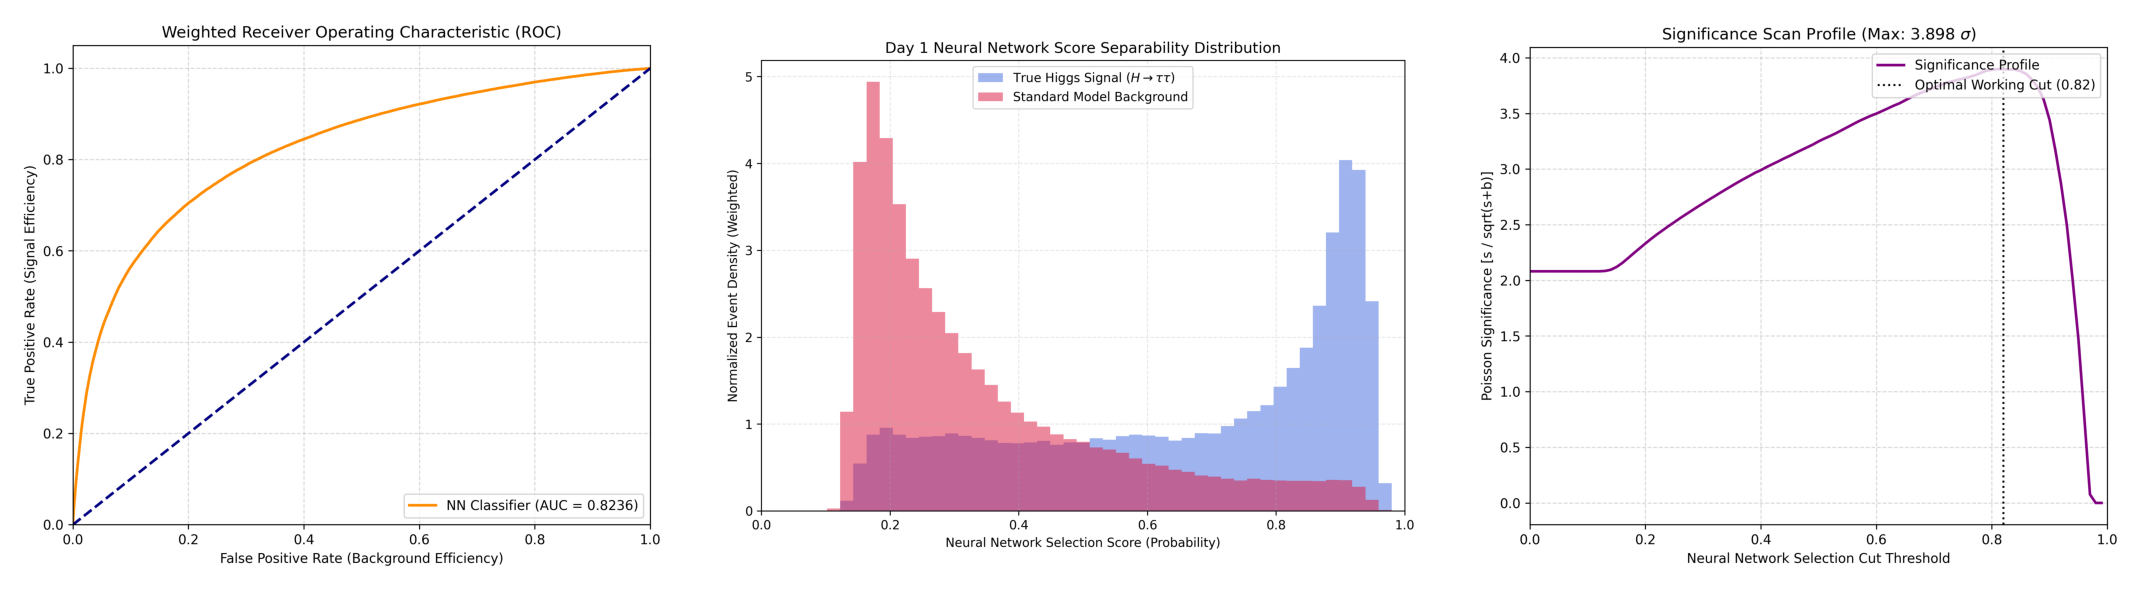

In [ ]:
import cv2
import matplotlib.pyplot as plt

print("1/3 - Calcul des prédictions sur l'ensemble de test...")
predictions = nn.predict(X_test)

print("\n2/3 - Génération des métriques et des graphiques physiques...")
calculate_weighted_roc(y_test, predictions, sample_weights=w_test)
plot_score_separability(y_test, predictions, sample_weights=w_test)

print("\n3/3 - Calcul du seuil de sélection optimal...")
optimal_cut, max_sig = optimize_poisson_significance(
    y_test, predictions, sample_weights=w_test
)

# --- Affichage des diagnostics générés ---
print("\n📊 TABLEAU DE BORD DES PERFORMANCES :")
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

img_roc = cv2.imread("nn_day1_roc_curve.png")
axes[0].imshow(cv2.cvtColor(img_roc, cv2.COLOR_BGR2RGB))
axes[0].axis("off")

img_dist = cv2.imread("nn_day1_score_distribution.png")
axes[1].imshow(cv2.cvtColor(img_dist, cv2.COLOR_BGR2RGB))
axes[1].axis("off")

img_sig = cv2.imread("nn_day1_significance_scan.png")
axes[2].imshow(cv2.cvtColor(img_sig, cv2.COLOR_BGR2RGB))
axes[2].axis("off")

plt.tight_layout()
plt.show()

learning curve

Dispositivo in uso: cuda
Epoca [10/100] -> Train Loss: 0.5589 | Val Loss: 0.5616 | Val Acc: 0.7792
Epoca [20/100] -> Train Loss: 0.3205 | Val Loss: 0.3244 | Val Acc: 0.9125
Epoca [30/100] -> Train Loss: 0.1380 | Val Loss: 0.1585 | Val Acc: 0.9542
Epoca [40/100] -> Train Loss: 0.0643 | Val Loss: 0.0887 | Val Acc: 0.9667
Epoca [50/100] -> Train Loss: 0.0371 | Val Loss: 0.0663 | Val Acc: 0.9708
Epoca [60/100] -> Train Loss: 0.0248 | Val Loss: 0.0562 | Val Acc: 0.9708
Epoca [70/100] -> Train Loss: 0.0183 | Val Loss: 0.0494 | Val Acc: 0.9792
Epoca [80/100] -> Train Loss: 0.0140 | Val Loss: 0.0465 | Val Acc: 0.9750
Epoca [90/100] -> Train Loss: 0.0109 | Val Loss: 0.0472 | Val Acc: 0.9750
Epoca [100/100] -> Train Loss: 0.0087 | Val Loss: 0.0482 | Val Acc: 0.9750


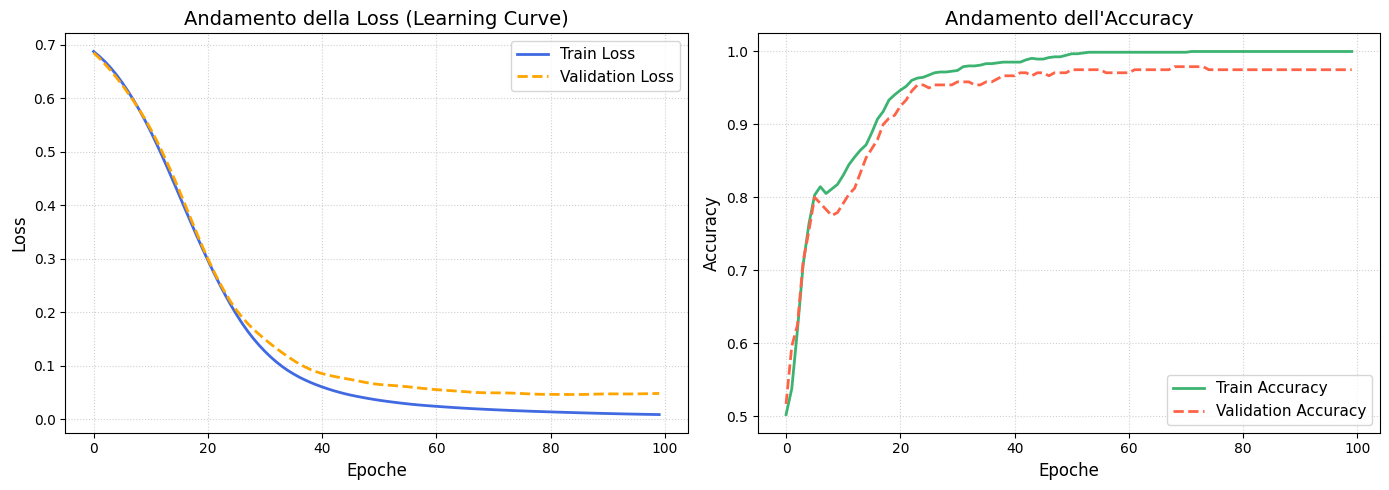

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np

# 1. Configurazione del dispositivo (usa la GPU se disponibile, es. su Colab)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo in uso: {device}")

# 2. Generazione di un dataset fittizio per classificazione binaria
np.random.seed(42)
torch.manual_seed(42)

# 1200 campioni, 10 feature ciascuno
X = np.random.randn(1200, 10).astype(np.float32)
# Generiamo i target (0 o 1) in base a una semplice regola lineare + rumore
y = (X[:, 0] + X[:, 1] > 0).astype(np.float32).reshape(-1, 1)

# Suddivisione in Train (80%) e Validation (20%)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Conversione in tensori PyTorch e spostamento sul dispositivo (CPU o GPU)
X_train_t = torch.tensor(X_train).to(device)
y_train_t = torch.tensor(y_train).to(device)
X_val_t = torch.tensor(X_val).to(device)
y_val_t = torch.tensor(y_val).to(device)


# 3. Definizione di una semplice rete neurale
class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(10, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, 1),
            nn.Sigmoid(),  # Per classificazione binaria
        )

    def forward(self, x):
        return self.network(x)


model = SimpleNN().to(device)
criterion = nn.BCELoss()  # Binary Cross Entropy Loss
optimizer = optim.Adam(model.parameters(), lr=0.01)

# 4. Liste per salvare la "storia" dell'addestramento (i dati per la Learning Curve)
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

epochs = 100

# 5. Loop di addestramento
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()

    # Forward pass (Train)
    train_outputs = model(X_train_t)
    train_loss = criterion(train_outputs, y_train_t)

    # Backward pass e ottimizzazione
    train_loss.backward()
    optimizer.step()

    # Calcolo accuratezza Train
    train_preds = (train_outputs > 0.5).float()
    train_acc = (train_preds == y_train_t).float().mean().item()

    # Validazione (senza calcolare i gradienti)
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val_t)
        val_loss = criterion(val_outputs, y_val_t)
        val_preds = (val_outputs > 0.5).float()
        val_acc = (val_preds == y_val_t).float().mean().item()

    # Salvataggio delle metriche nella history
    history["train_loss"].append(train_loss.item())
    history["val_loss"].append(val_loss.item())
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    # Stampa l'avanzamento ogni 10 epoche
    if (epoch + 1) % 10 == 0:
        print(
            f"Epoca [{epoch+1}/{epochs}] -> Train Loss: {train_loss.item():.4f} | Val Loss: {val_loss.item():.4f} | Val Acc: {val_acc:.4f}"
        )

# 6. PLOTTING DELLA LEARNING CURVE
plt.figure(figsize=(14, 5))

# Grafico della Loss (Funzione di perdita)
plt.subplot(1, 2, 1)
plt.plot(history["train_loss"], label="Train Loss", color="royalblue", linewidth=2)
plt.plot(
    history["val_loss"],
    label="Validation Loss",
    color="orange",
    linewidth=2,
    linestyle="--",
)
plt.title("Andamento della Loss (Learning Curve)", fontsize=14)
plt.xlabel("Epoche", fontsize=12)
plt.ylabel("Loss", fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle=":", alpha=0.6)

# Grafico dell'Accuracy (Accuratezza)
plt.subplot(1, 2, 2)
plt.plot(
    history["train_acc"], label="Train Accuracy", color="mediumseagreen", linewidth=2
)
plt.plot(
    history["val_acc"],
    label="Validation Accuracy",
    color="tomato",
    linewidth=2,
    linestyle="--",
)
plt.title("Andamento dell'Accuracy", fontsize=14)
plt.xlabel("Epoche", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()


plt.show()